<a href="https://colab.research.google.com/github/MukRodrigues/Projetos-Python/blob/main/SRAG-Brasil-2019-2026/SRAG_REG_PREV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SRAG — Regressão, previsão e classificação multiclasse

#### Bibliotecas

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from IPython.display import display
import sklearn
import joblib
import warnings


from __future__ import annotations

import argparse
import json
import math
import re
import unicodedata
from dataclasses import dataclass
from datetime import datetime, timezone
from html.parser import HTMLParser
from pathlib import Path
from typing import Callable
from urllib.request import Request, urlopen

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, SplineTransformer

################################
import importlib.util
import sys
import subprocess
if importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
from IPython.display import display

from pathlib import Path
from itertools import combinations
import json
import warnings
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t as student_t, poisson
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, cohen_kappa_score

#!/usr/bin/env python3
# Site do dadaset SRAG:  https://dadosabertos.saude.gov.br/dataset/srag-2019-a-2026

#### Dataset

In [2]:
"""
Regressão das curvas semanais de doenças respiratórias (Brasil, 2019--2025).

O programa:
1. baixa o gráfico Plotly disponibilizado pelo repositório do CGCOVID;
2. extrai as séries semanais de incidência;
3. exclui SARS-CoV-2 e o ano de 2026;
4. ajusta modelos lineares nos parâmetros para cada combinação doença--ano;
5. seleciona o modelo por validação cruzada em blocos temporais;
6. salva métricas, melhores modelos, previsões e gráficos.

Modelos candidatos:
- polinômios de graus 1 a 5;
- regressões harmônicas com um e dois harmônicos;
- spline cúbica com regularização Ridge.

Uso básico:
    python regressao_doencas_respiratorias.py

Escolhendo outra pasta de saída:
    python regressao_doencas_respiratorias.py --saida resultados_regressao

Execução sem gerar os 77 gráficos individuais:
    python regressao_doencas_respiratorias.py --sem-graficos
"""

URL_PADRAO = (
    "https://gitlab.com/cgcovid/dados-publicos/-/raw/main/"
    "S%C3%A9ries%20hist%C3%B3ricas/Srag/Brasil/"
    "serie_historica_casos.html"
)

PASTA_REGRESSAO = Path("resultados_regressao_respiratorias")

ANO_INICIAL = 2019
ANO_FINAL = 2026
SEMANAS_POR_BLOCO = 53
VIRUS_EXCLUIDOS = {"SARS-CoV-2"}
SEMENTE = 42


class ExtratorJSON(HTMLParser):
    """Extrai o conteúdo de scripts HTML do tipo application/json."""

    def __init__(self) -> None:
        super().__init__()
        self._em_json = False
        self._partes: list[str] = []
        self.blocos: list[str] = []

    def handle_starttag(self, tag: str, attrs: list[tuple[str, str | None]]) -> None:
        if tag.lower() != "script":
            return
        atributos = {chave.lower(): valor for chave, valor in attrs}
        if atributos.get("type", "").lower() == "application/json":
            self._em_json = True
            self._partes = []

    def handle_data(self, data: str) -> None:
        if self._em_json:
            self._partes.append(data)

    def handle_endtag(self, tag: str) -> None:
        if tag.lower() == "script" and self._em_json:
            self.blocos.append("".join(self._partes))
            self._em_json = False
            self._partes = []


@dataclass(frozen=True)
class EspecificacaoModelo:
    nome: str
    fabrica: Callable[[], Pipeline]
    ordem_simplicidade: int
    familia: str


def baixar_html(url: str, timeout: int = 60) -> str:
    """Baixa o HTML usando um User-Agent explícito."""
    requisicao = Request(
        url,
        headers={"User-Agent": "Mozilla/5.0 (analise-academica-srag/1.0)"},
    )
    with urlopen(requisicao, timeout=timeout) as resposta:
        codificacao = resposta.headers.get_content_charset() or "utf-8"
        return resposta.read().decode(codificacao)


def localizar_dados_plotly(html: str) -> list[dict]:
    """Localiza a lista de séries armazenada no JSON interno do Plotly."""
    extrator = ExtratorJSON()
    extrator.feed(html)

    for bloco in extrator.blocos:
        try:
            objeto = json.loads(bloco)
        except json.JSONDecodeError:
            continue

        if not isinstance(objeto, dict):
            continue
        conteudo_x = objeto.get("x")
        if not isinstance(conteudo_x, dict):
            continue
        dados = conteudo_x.get("data")
        if isinstance(dados, list) and dados:
            return dados

    raise ValueError("Não foi possível localizar as séries do Plotly no arquivo HTML.")


def construir_dataframe(series_plotly: list[dict]) -> pd.DataFrame:
    """Converte as séries do Plotly para o formato longo do Pandas."""
    registros: list[dict] = []

    for serie in series_plotly:
        nome = serie.get("name")
        valores_x = serie.get("x", [])
        valores_y = serie.get("y", [])

        if not nome or not isinstance(valores_x, list) or not isinstance(valores_y, list):
            continue
        if len(valores_x) != len(valores_y):
            raise ValueError(f"Série {nome!r} possui comprimentos incompatíveis em x e y.")

        for indice, casos in zip(valores_x, valores_y):
            registros.append(
                {
                    "indice_temporal": indice,
                    "virus": str(nome),
                    "casos": casos,
                }
            )

    df = pd.DataFrame(registros)
    if df.empty:
        raise ValueError("Nenhuma observação foi extraída do gráfico.")

    df["indice_temporal"] = pd.to_numeric(df["indice_temporal"], errors="coerce")
    df["casos"] = pd.to_numeric(df["casos"], errors="coerce")
    df = df.dropna(subset=["indice_temporal", "casos", "virus"]).copy()
    df["indice_temporal"] = df["indice_temporal"].astype(int)

    df["ano"] = ANO_INICIAL + (df["indice_temporal"] - 1) // SEMANAS_POR_BLOCO
    df["semana"] = 1 + (df["indice_temporal"] - 1) % SEMANAS_POR_BLOCO
    df["ano_semana"] = (
        df["ano"].astype(str) + "-SE" + df["semana"].astype(str).str.zfill(2)
    )

    # tau é fixado em [0, 1], considerando as 53 posições epidemiológicas possíveis.
    # Isso evita potências de números grandes nos modelos polinomiais.
    df["tau"] = (df["semana"] - 1) / (SEMANAS_POR_BLOCO - 1)

    return df.sort_values(["ano", "semana", "virus"]).reset_index(drop=True)


def filtrar_periodo(df: pd.DataFrame) -> pd.DataFrame:
    """Mantém 2019--2026 e remove explicitamente SARS-CoV-2."""
    mascara = (
        df["ano"].between(ANO_INICIAL, ANO_FINAL)
        & ~df["virus"].isin(VIRUS_EXCLUIDOS)
    )
    resultado = df.loc[mascara].copy()
    if resultado.empty:
        raise ValueError("O filtro solicitado não produziu observações.")
    return resultado

df_2019_2026 = pd.read_csv("https://github.com/MukRodrigues/Projetos-Python/raw/628cb0e2312f393b98d4d29615018b256e5d3cc5/SRAG-Brasil-2019-2026/dados_SRAG_gitlab_15092026.csv")


#### Modelos de Regressão

###### Polinômios de 1 até 5 grau, spline cúbinca e harmônica (senos e cossenos).

In [3]:
def _caracteristicas_harmonicas(x: np.ndarray, n_harmonicos: int) -> np.ndarray:
    """Cria senos e cossenos a partir do tempo normalizado tau."""
    tau = np.asarray(x, dtype=float).reshape(-1)
    colunas: list[np.ndarray] = []
    for k in range(1, n_harmonicos + 1):
        colunas.append(np.sin(2.0 * np.pi * k * tau))
        colunas.append(np.cos(2.0 * np.pi * k * tau))
    return np.column_stack(colunas)


def criar_modelos() -> list[EspecificacaoModelo]:
    """Define todos os modelos candidatos."""
    modelos: list[EspecificacaoModelo] = []

    nomes_graus = {
        1: "linear",
        2: "polinomial_grau_2",
        3: "polinomial_grau_3",
        4: "polinomial_grau_4",
        5: "polinomial_grau_5",
    }

    for grau, nome in nomes_graus.items():
        modelos.append(
            EspecificacaoModelo(
                nome=nome,
                fabrica=lambda grau=grau: Pipeline(
                    steps=[
                        (
                            "caracteristicas",
                            PolynomialFeatures(degree=grau, include_bias=False),
                        ),
                        ("regressor", LinearRegression()),
                    ]
                ),
                ordem_simplicidade=grau + 1,
                familia="polinomial",
            )
        )

    for n_harmonicos in (1, 2):
        modelos.append(
            EspecificacaoModelo(
                nome=f"harmonico_{n_harmonicos}",
                fabrica=lambda n=n_harmonicos: Pipeline(
                    steps=[
                        (
                            "caracteristicas",
                            FunctionTransformer(
                                _caracteristicas_harmonicas,
                                kw_args={"n_harmonicos": n},
                                validate=False,
                            ),
                        ),
                        ("regressor", LinearRegression()),
                    ]
                ),
                ordem_simplicidade=1 + 2 * n_harmonicos,
                familia="harmonico",
            )
        )

    modelos.append(
        EspecificacaoModelo(
            nome="spline_cubica",
            fabrica=lambda: Pipeline(
                steps=[
                    (
                        "caracteristicas",
                        SplineTransformer(
                            degree=3,
                            n_knots=5,
                            knots="quantile",
                            include_bias=False,
                            extrapolation="linear",
                        ),
                    ),
                    ("regressor", Ridge(alpha=1.0e-3)),
                ]
            ),
            ordem_simplicidade=7,
            familia="spline",
        )
    )

    return modelos


def prever_validacao_blocos(
    modelo: Pipeline,
    x: np.ndarray,
    y: np.ndarray,
    n_blocos: int = 5,
) -> np.ndarray:
    """
    Produz previsões fora da amostra em blocos contíguos.

    O objetivo é escolher uma função descritiva para toda a curva anual. Por
    isso, cada bloco é retirado e os demais blocos são usados no ajuste. Este
    procedimento não deve ser interpretado como validação de uma previsão do
    futuro; para forecasting seria necessário usar janelas expansivas.
    """
    if len(y) < n_blocos:
        raise ValueError("Número de observações insuficiente para a validação.")

    previsoes = np.full(len(y), np.nan, dtype=float)
    divisor = KFold(n_splits=n_blocos, shuffle=False)

    for treino, teste in divisor.split(x):
        modelo_bloco = clone(modelo)
        modelo_bloco.fit(x[treino], y[treino])
        previsoes[teste] = modelo_bloco.predict(x[teste])

    return previsoes




###### Resultados

In [4]:

def numero_parametros(modelo: Pipeline) -> int:
    """Conta intercepto e coeficientes estimados pelo regressor final."""
    regressor = modelo.named_steps["regressor"]
    coeficientes = np.asarray(regressor.coef_).reshape(-1)
    return int(coeficientes.size + 1)


def calcular_metricas(
    y: np.ndarray,
    predicao_ajuste: np.ndarray,
    predicao_cv: np.ndarray,
    k: int,
) -> dict[str, float | int]:
    """Calcula métricas de ajuste, informação e validação."""
    n = len(y)
    residuos = y - predicao_ajuste
    rss = float(np.sum(residuos**2))
    rss_seguro = max(rss, np.finfo(float).tiny)

    r2 = float(r2_score(y, predicao_ajuste))
    if n > k:
        r2_ajustado = 1.0 - (1.0 - r2) * (n - 1) / (n - k)
    else:
        r2_ajustado = math.nan

    aic = n * math.log(rss_seguro / n) + 2 * k
    bic = n * math.log(rss_seguro / n) + k * math.log(n)
    if n > k + 1:
        aicc = aic + (2 * k * (k + 1)) / (n - k - 1)
    else:
        aicc = math.nan

    return {
        "n_observacoes": n,
        "n_parametros": k,
        "rmse_ajuste": float(np.sqrt(mean_squared_error(y, predicao_ajuste))),
        "mae_ajuste": float(mean_absolute_error(y, predicao_ajuste)),
        "r2": r2,
        "r2_ajustado": r2_ajustado,
        "aic": float(aic),
        "aicc": float(aicc),
        "bic": float(bic),
        "rmse_cv": float(np.sqrt(mean_squared_error(y, predicao_cv))),
        "mae_cv": float(mean_absolute_error(y, predicao_cv)),
        "previsoes_negativas_ajuste": int(np.sum(predicao_ajuste < 0)),
        "previsoes_negativas_cv": int(np.sum(predicao_cv < 0)),
    }


def extrair_parametros(
    modelo: Pipeline,
    especificacao: EspecificacaoModelo,
) -> tuple[str, str]:
    """Retorna parâmetros em JSON e uma representação legível da função."""
    regressor = modelo.named_steps["regressor"]
    intercepto = float(np.asarray(regressor.intercept_).reshape(-1)[0])
    coeficientes = np.asarray(regressor.coef_, dtype=float).reshape(-1)

    parametros = {
        "intercepto": intercepto,
        "coeficientes": coeficientes.tolist(),
        "variavel_temporal": "tau=(semana-1)/52",
    }

    if especificacao.familia == "polinomial":
        termos = [f"{intercepto:.8g}"]
        for potencia, coeficiente in enumerate(coeficientes, start=1):
            termos.append(f"({coeficiente:.8g})*tau^{potencia}")
        equacao = "y_hat = " + " + ".join(termos)

    elif especificacao.familia == "harmonico":
        termos = [f"{intercepto:.8g}"]
        for i in range(0, len(coeficientes), 2):
            k = i // 2 + 1
            termos.append(f"({coeficientes[i]:.8g})*sin(2*pi*{k}*tau)")
            termos.append(f"({coeficientes[i + 1]:.8g})*cos(2*pi*{k}*tau)")
        equacao = "y_hat = " + " + ".join(termos)

    else:
        parametros["observacao"] = (
            "Os coeficientes multiplicam as bases B-spline cúbicas produzidas "
            "por SplineTransformer(n_knots=5, degree=3)."
        )
        equacao = "y_hat = intercepto + soma_j coeficiente_j * B_j(tau)"

    return json.dumps(parametros, ensure_ascii=False), equacao


def nome_seguro(texto: str) -> str:
    """Converte um rótulo em nome de arquivo portátil."""
    normalizado = unicodedata.normalize("NFKD", texto)
    sem_acentos = "".join(c for c in normalizado if not unicodedata.combining(c))
    return re.sub(r"[^A-Za-z0-9_-]+", "_", sem_acentos).strip("_").lower()


def salvar_grafico(
    grupo: pd.DataFrame,
    predicao: np.ndarray,
    nome_modelo: str,
    metricas: pd.Series,
    destino: Path,
) -> None:
    """Salva o gráfico observado versus ajustado."""
    ano = int(grupo["ano"].iloc[0])
    virus = str(grupo["virus"].iloc[0])

    fig, eixo = plt.subplots(figsize=(10.5, 5.5))
    eixo.scatter(
        grupo["semana"],
        grupo["casos"],
        s=30,
        color="#174A7E",
        alpha=0.82,
        label="Casos observados",
        zorder=3,
    )
    eixo.plot(
        grupo["semana"],
        predicao,
        color="#C33C2D",
        linewidth=2.3,
        label=f"Ajuste: {nome_modelo}",
    )
    eixo.axhline(0, color="black", linewidth=0.7, alpha=0.35)
    eixo.set(
        xlabel="Semana epidemiológica",
        ylabel="Número de casos",
        title=f"{virus} — Brasil, {ano}",
    )
    texto = (
        f"RMSE-CV = {metricas['rmse_cv']:.2f}\n"
        f"MAE-CV = {metricas['mae_cv']:.2f}\n"
        f"R² ajustado = {metricas['r2_ajustado']:.3f}"
    )
    eixo.text(
        0.985,
        0.965,
        texto,
        transform=eixo.transAxes,
        ha="right",
        va="top",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.88},
    )
    eixo.grid(alpha=0.22)
    eixo.legend(loc="upper left")
    fig.tight_layout()
    fig.savefig(destino, dpi=170, bbox_inches="tight")
    plt.close(fig)


def selecionar_modelo(metricas_grupo: pd.DataFrame) -> pd.Series:
    """
    Seleciona o menor modelo dentro de 1% do menor RMSE-CV.

    Essa regra evita escolher um modelo muito mais complexo por uma melhora
    numericamente irrelevante.
    """
    menor_rmse = float(metricas_grupo["rmse_cv"].min())
    limite = menor_rmse * 1.01 + 1.0e-12
    candidatos = metricas_grupo.loc[metricas_grupo["rmse_cv"] <= limite]
    return candidatos.sort_values(
        ["ordem_simplicidade", "rmse_cv", "bic", "modelo"]
    ).iloc[0]


def executar_analise(
    df: pd.DataFrame,
    pasta_saida: Path,
    gerar_graficos: bool = True,
    n_blocos: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Ajusta, compara e seleciona os modelos para as 77 curvas."""
    modelos = criar_modelos()
    modelos_por_nome = {modelo.nome: modelo for modelo in modelos}

    metricas_registros: list[dict] = []
    melhores_registros: list[dict] = []
    predicoes_registros: list[dict] = []

    pasta_graficos = pasta_saida / "graficos"
    if gerar_graficos:
        pasta_graficos.mkdir(parents=True, exist_ok=True)

    grupos = list(df.groupby(["ano", "virus"], sort=True))
    total = len(grupos)

    for posicao, ((ano, virus), grupo_original) in enumerate(grupos, start=1):
        grupo = grupo_original.sort_values("semana").reset_index(drop=True)
        x = grupo[["tau"]].to_numpy(dtype=float)
        y = grupo["casos"].to_numpy(dtype=float)

        metricas_da_curva: list[dict] = []

        for especificacao in modelos:
            modelo = especificacao.fabrica()
            predicao_cv = prever_validacao_blocos(modelo, x, y, n_blocos=n_blocos)

            modelo.fit(x, y)
            predicao_ajuste = np.asarray(modelo.predict(x), dtype=float)
            k = numero_parametros(modelo)

            metricas = calcular_metricas(
                y=y,
                predicao_ajuste=predicao_ajuste,
                predicao_cv=predicao_cv,
                k=k,
            )
            registro = {
                "ano": int(ano),
                "virus": str(virus),
                "modelo": especificacao.nome,
                "familia": especificacao.familia,
                "ordem_simplicidade": especificacao.ordem_simplicidade,
                **metricas,
            }
            metricas_registros.append(registro)
            metricas_da_curva.append(registro)

        tabela_curva = pd.DataFrame(metricas_da_curva)
        vencedor = selecionar_modelo(tabela_curva)
        especificacao_vencedora = modelos_por_nome[str(vencedor["modelo"])]
        modelo_vencedor = especificacao_vencedora.fabrica()
        modelo_vencedor.fit(x, y)
        predicao_vencedora = np.asarray(modelo_vencedor.predict(x), dtype=float)
        parametros, equacao = extrair_parametros(modelo_vencedor, especificacao_vencedora)

        melhor_registro = vencedor.to_dict()
        melhor_registro.update(
            {
                "parametros": parametros,
                "equacao": equacao,
                "semana_inicial": int(grupo["semana"].min()),
                "semana_final": int(grupo["semana"].max()),
                "total_casos_ano": float(y.sum()),
                "pico_casos": float(y.max()),
                "semana_pico_observado": int(grupo.loc[np.argmax(y), "semana"]),
            }
        )
        melhores_registros.append(melhor_registro)

        for i, linha in grupo.iterrows():
            predicoes_registros.append(
                {
                    "ano": int(ano),
                    "semana": int(linha["semana"]),
                    "ano_semana": linha["ano_semana"],
                    "virus": str(virus),
                    "casos_observados": float(linha["casos"]),
                    "casos_ajustados": float(predicao_vencedora[i]),
                    "residuo": float(linha["casos"] - predicao_vencedora[i]),
                    "modelo": especificacao_vencedora.nome,
                }
            )

        if gerar_graficos:
            arquivo = pasta_graficos / f"{int(ano)}_{nome_seguro(str(virus))}.png"
            salvar_grafico(
                grupo,
                predicao_vencedora,
                especificacao_vencedora.nome,
                vencedor,
                arquivo,
            )

        print(
            f"[{posicao:02d}/{total:02d}] {int(ano)} | {virus}: "
            f"{especificacao_vencedora.nome}"
        )

    metricas_df = pd.DataFrame(metricas_registros).sort_values(
        ["ano", "virus", "rmse_cv", "ordem_simplicidade"]
    )
    melhores_df = pd.DataFrame(melhores_registros).sort_values(["ano", "virus"])
    predicoes_df = pd.DataFrame(predicoes_registros).sort_values(
        ["ano", "virus", "semana"]
    )
    return metricas_df, melhores_df, predicoes_df


def salvar_resultados(
    pasta_saida: Path,
    df_filtrado: pd.DataFrame,
    metricas: pd.DataFrame,
    melhores: pd.DataFrame,
    predicoes: pd.DataFrame,
    url: str,
) -> None:
    """Salva os resultados tabulares e os metadados da execução."""
    pasta_saida.mkdir(parents=True, exist_ok=True)

    df_filtrado.to_csv(
        pasta_saida / "dados_processados_2019_2025_sem_covid.csv",
        index=False,
        encoding="utf-8-sig",
    )
    metricas.to_csv(
        pasta_saida / "metricas_todos_modelos.csv",
        index=False,
        encoding="utf-8-sig",
    )
    melhores.to_csv(
        pasta_saida / "melhores_modelos.csv",
        index=False,
        encoding="utf-8-sig",
    )
    predicoes.to_csv(
        pasta_saida / "ajustes_melhores_modelos.csv",
        index=False,
        encoding="utf-8-sig",
    )

    resumo = (
        melhores.groupby(["modelo", "familia"], as_index=False)
        .agg(
            quantidade=("modelo", "size"),
            rmse_cv_mediano=("rmse_cv", "median"),
            r2_ajustado_mediano=("r2_ajustado", "median"),
        )
        .sort_values(["quantidade", "modelo"], ascending=[False, True])
    )
    resumo.to_csv(
        pasta_saida / "resumo_modelos_vencedores.csv",
        index=False,
        encoding="utf-8-sig",
    )

    metadados = {
        "fonte": url,
        "baixado_em_utc": datetime.now(timezone.utc).isoformat(),
        "anos_incluidos": [ANO_INICIAL, ANO_FINAL],
        "virus_excluidos": sorted(VIRUS_EXCLUIDOS),
        "n_doencas": int(df_filtrado["virus"].nunique()),
        "n_curvas_doenca_ano": int(melhores.shape[0]),
        "criterio_selecao": (
            "Modelo mais simples entre aqueles com RMSE-CV até 1% acima do menor "
            "RMSE-CV, usando validação em cinco blocos contíguos."
        ),
        "aviso": (
            "A validação em blocos foi usada para selecionar uma função descritiva "
            "da curva anual; não constitui validação prospectiva de forecasting."
        ),
    }
    (pasta_saida / "metadados_execucao.json").write_text(
        json.dumps(metadados, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def validar_estrutura(df: pd.DataFrame) -> None:
    """Exibe e valida a cobertura temporal antes da modelagem."""
    cobertura = (
        df.groupby("ano", as_index=False)
        .agg(
            semanas=("semana", "nunique"),
            semana_inicial=("semana", "min"),
            semana_final=("semana", "max"),
            doencas=("virus", "nunique"),
        )
        .sort_values("ano")
    )
    print("\nCobertura do conjunto analisado:")
    print(cobertura.to_string(index=False))

    anos_encontrados = set(cobertura["ano"].astype(int))
    anos_esperados = set(range(ANO_INICIAL, ANO_FINAL + 1))
    if anos_encontrados != anos_esperados:
        raise ValueError(
            f"Cobertura anual inesperada. Esperado: {sorted(anos_esperados)}; "
            f"encontrado: {sorted(anos_encontrados)}."
        )

    if "SARS-CoV-2" in set(df["virus"]):
        raise AssertionError("SARS-CoV-2 permaneceu no conjunto após o filtro.")


def interpretar_argumentos() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Compara regressões para curvas semanais de doenças respiratórias."
    )
    parser.add_argument(
        "--url",
        default=URL_PADRAO,
        help="Endereço raw do arquivo HTML do Plotly.",
    )
    parser.add_argument(
        "--saida",
        type=Path,
        default=PASTA_REGRESSAO,
        help="Pasta em que os resultados serão gravados.",
    )
    parser.add_argument(
        "--sem-graficos",
        action="store_true",
        help="Não gera os gráficos PNG individuais.",
    )
    parser.add_argument(
        "--blocos-cv",
        type=int,
        default=5,
        help="Número de blocos contíguos da validação cruzada (padrão: 5).",
    )
    args, unknown = parser.parse_known_args() # Modified line
    return args # Modified line


def main() -> None:
    argumentos = interpretar_argumentos()
    np.random.seed(SEMENTE)

    if argumentos.blocos_cv < 2:
        raise ValueError("--blocos-cv deve ser pelo menos 2.")

    print("Baixando e extraindo o conjunto de dados...")
    html = baixar_html(argumentos.url)
    series_plotly = localizar_dados_plotly(html)
    global df_completo, PASTA_REGRESSAO
    PASTA_REGRESSAO = argumentos.saida
    df_completo = construir_dataframe(series_plotly)
    df_filtrado = filtrar_periodo(df_completo)
    validar_estrutura(df_filtrado)

    print("\nDoenças incluídas:")
    for nome in sorted(df_filtrado["virus"].unique()):
        print(f"- {nome}")

    print("\nAjustando e comparando os modelos...")
    argumentos.saida.mkdir(parents=True, exist_ok=True)
    df_completo.to_csv(argumentos.saida / "dados_processados_completos.csv", index=False)
    metricas, melhores, predicoes = executar_analise(
        df=df_filtrado,
        pasta_saida=argumentos.saida,
        gerar_graficos=not argumentos.sem_graficos,
        n_blocos=argumentos.blocos_cv,
    )

    salvar_resultados(
        pasta_saida=argumentos.saida,
        df_filtrado=df_filtrado,
        metricas=metricas,
        melhores=melhores,
        predicoes=predicoes,
        url=argumentos.url,
    )

    print("\nAnálise concluída.")
    print(f"Resultados salvos em: {argumentos.saida.resolve()}")
    print("\nModelos vencedores:")
    print(melhores["modelo"].value_counts().to_string())


if __name__ == "__main__":
    main()

Baixando e extraindo o conjunto de dados...

Cobertura do conjunto analisado:
 ano  semanas  semana_inicial  semana_final  doencas
2019       52               1            52       11
2020       53               1            53       11
2021       52               1            52       11
2022       52               1            52       11
2023       52               1            52       11
2024       52               1            52       11
2025       53               1            53       11
2026       34               1            34       11

Doenças incluídas:
- Adenovírus
- Bocavírus
- Influenza A(H1N1)pdm09
- Influenza A(H3N2)
- Influenza A(não subtipada)
- Influenza B
- Metapneumovírus
- Outros vírus respiratórios
- Parainfluenza
- Rinovírus
- VSR

Ajustando e comparando os modelos...
[01/88] 2019 | Adenovírus: polinomial_grau_2
[02/88] 2019 | Bocavírus: harmonico_2
[03/88] 2019 | Influenza A(H1N1)pdm09: harmonico_1
[04/88] 2019 | Influenza A(H3N2): harmonico_2
[05/88] 2019 

#### Previsão para 2026

In [5]:
df_filtrado = pd.read_csv(PASTA_REGRESSAO / "dados_processados_2019_2025_sem_covid.csv")

def construir_variaveis_previsao(ano, semana, n_harmonicos=2):
    """
    Constrói tendência, sazonalidade e interações.
    """

    ano = np.asarray(ano, dtype=float)
    semana = np.asarray(semana, dtype=float)

    # Tendência normalizada: 2019 -> 0 e 2026 -> 1
    tendencia = (ano - 2019) / 7

    # Indicador para o período mais atípico da pandemia
    pandemia = np.isin(
        ano.astype(int),
        [2020, 2021]
    ).astype(float)

    colunas = [
        tendencia,
        pandemia
    ]

    for k in range(1, n_harmonicos + 1):

        seno = np.sin(
            2 * np.pi * k * (semana - 1) / 53
        )

        cosseno = np.cos(
            2 * np.pi * k * (semana - 1) / 53
        )

        colunas.extend([
            seno,
            cosseno,
            tendencia * seno,
            tendencia * cosseno
        ])

    return np.column_stack(colunas)

In [6]:
# ============================================================
# 1. Dados de treinamento: somente 2019--2025
# ============================================================

treino = df_filtrado[
    df_filtrado["ano"].between(2019, 2025)
].copy()


# ============================================================
# 2. Semanas que serão previstas em 2026
# ============================================================

futuro_2026 = pd.DataFrame({
    "ano": 2026,
    "semana": np.arange(1, 54)
})

previsoes = []


# ============================================================
# 3. Um modelo para cada doença
# ============================================================

for virus, grupo in treino.groupby("virus"):

    grupo = grupo.sort_values(
        ["ano", "semana"]
    ).copy()

    X_treino = construir_variaveis_previsao(
        ano=grupo["ano"],
        semana=grupo["semana"],
        n_harmonicos=2
    )

    y_treino = grupo["casos"].to_numpy()

    modelo = PoissonRegressor(
        alpha=0.01,
        max_iter=20000
    )

    modelo.fit(X_treino, y_treino)

    X_2026 = construir_variaveis_previsao(
        ano=futuro_2026["ano"],
        semana=futuro_2026["semana"],
        n_harmonicos=2
    )

    y_2026 = modelo.predict(X_2026)

    resultado_virus = futuro_2026.copy()
    resultado_virus["virus"] = virus
    resultado_virus["casos_previstos"] = y_2026

    previsoes.append(resultado_virus)


previsoes_2026 = pd.concat(
    previsoes,
    ignore_index=True
)
previsoes_2026.to_csv(PASTA_REGRESSAO / "previsoes_2026.csv",  index=False)

print(previsoes_2026.head(20))

     ano  semana       virus  casos_previstos
0   2026       1  Adenovírus        60.938827
1   2026       2  Adenovírus        55.663593
2   2026       3  Adenovírus        52.311398
3   2026       4  Adenovírus        50.728460
4   2026       5  Adenovírus        50.842029
5   2026       6  Adenovírus        52.669753
6   2026       7  Adenovírus        56.322212
7   2026       8  Adenovírus        61.998530
8   2026       9  Adenovírus        69.971467
9   2026      10  Adenovírus        80.555252
10  2026      11  Adenovírus        94.047929
11  2026      12  Adenovírus       110.642148
12  2026      13  Adenovírus       130.306636
13  2026      14  Adenovírus       152.656105
14  2026      15  Adenovírus       176.846910
15  2026      16  Adenovírus       201.549996
16  2026      17  Adenovírus       225.047955
17  2026      18  Adenovírus       245.470249
18  2026      19  Adenovírus       261.125926
19  2026      20  Adenovírus       270.841494


##### Gráfico - Casos por vírus

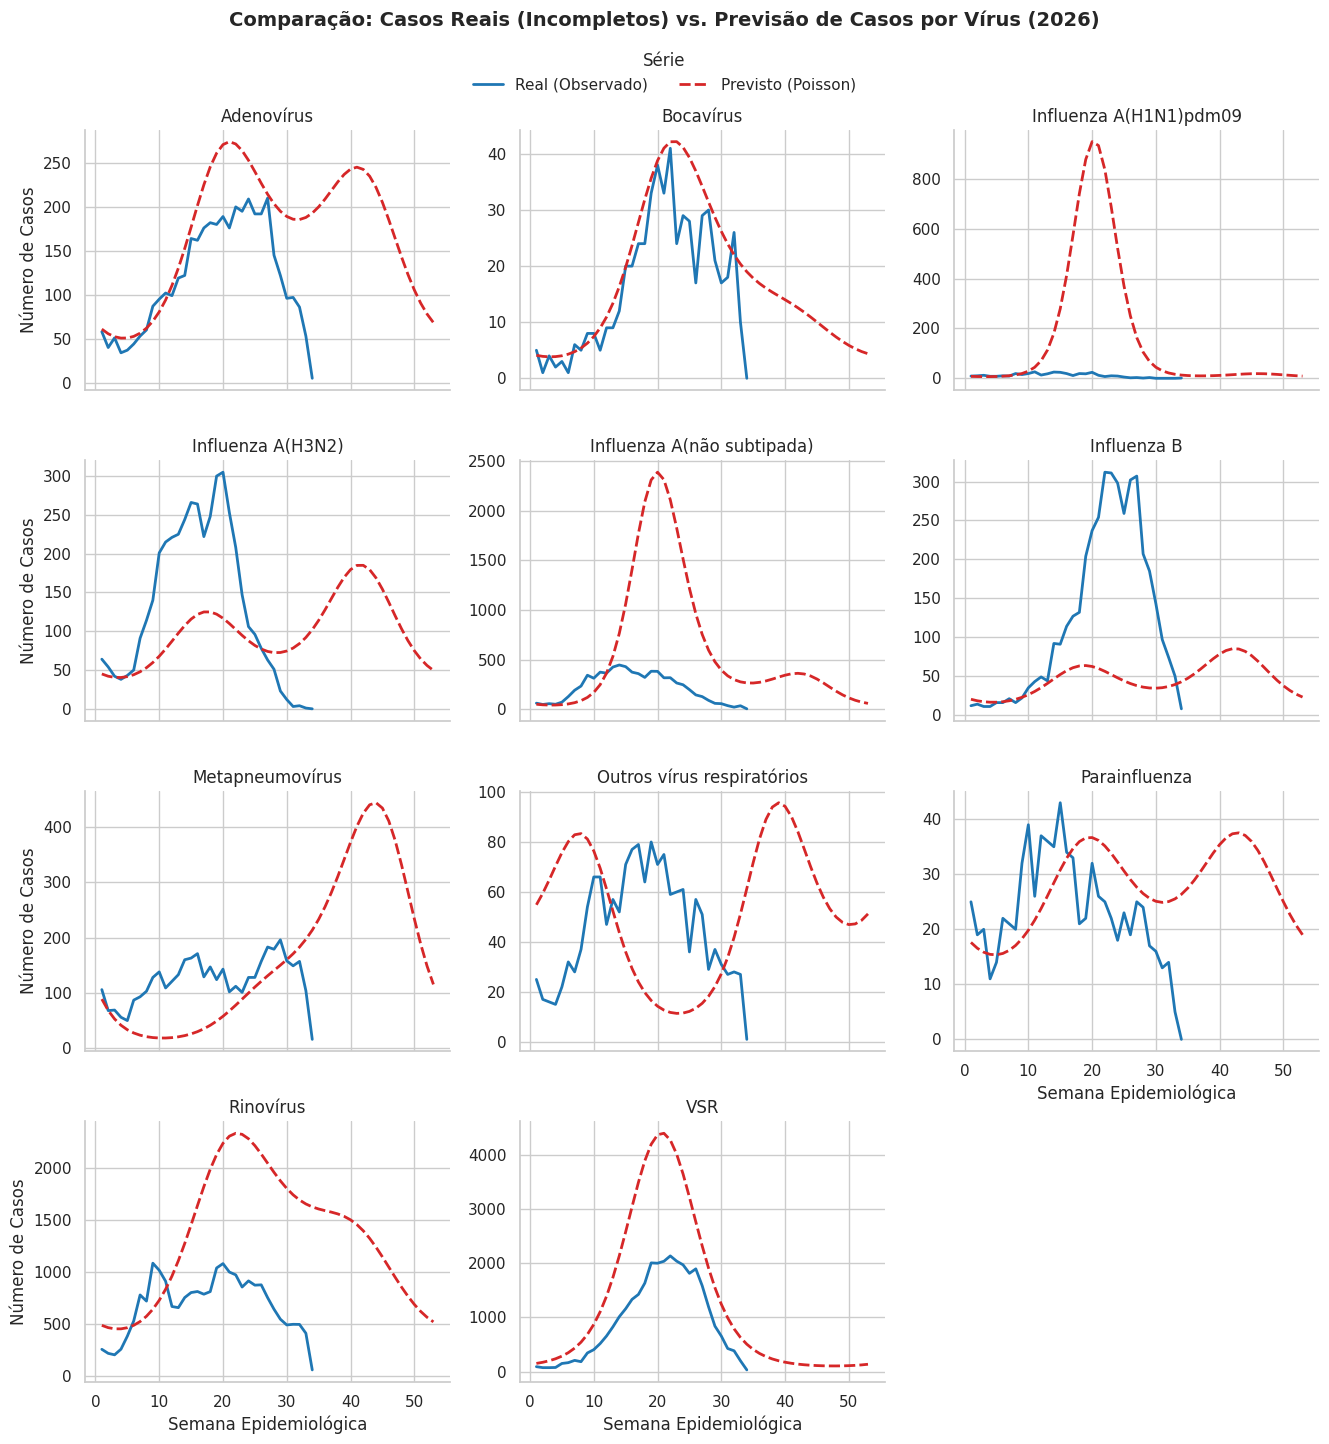

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
%matplotlib inline

# 1. Filtrar dados reais de 2026 presentes no dataframe completo
reais_2026 = df_2019_2026[(df_2019_2026['ano'] == 2026)  & (df_2019_2026['virus'] != "SARS-CoV-2")].copy()

# 2. Preparar e padronizar os dados reais para a junção
reais_plot = reais_2026[['semana', 'virus', 'casos']].copy()
reais_plot = reais_plot.rename(columns={'casos': 'Casos'})
reais_plot['Tipo'] = 'Real (Observado)'

# 3. Preparar e padronizar os dados previstos para a junção
previstos_plot = previsoes_2026[['semana', 'virus', 'casos_previstos']].copy()
previstos_plot = previstos_plot.rename(columns={'casos_previstos': 'Casos'})
previstos_plot['Tipo'] = 'Previsto (Poisson)'

# 4. Concatenar ambos os conjuntos de dados
dados_comparativo_2026 = pd.concat([reais_plot, previstos_plot], ignore_index=True)

# 5. Criar o gráfico facetado comparando Real vs Previsto para cada vírus
sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=dados_comparativo_2026,
    x='semana',
    y='Casos',
    hue='Tipo',
    style='Tipo',
    col='virus',
    kind='line',
    col_wrap=3,
    height=3.5, aspect=1.1,
    facet_kws={'sharey': False, 'sharex': True},
    palette={'Real (Observado)': '#1f77b4', 'Previsto (Poisson)': '#d62728'},
    linewidth=2
)

# Ajustar títulos e rótulos do layout
g.set_axis_labels('Semana Epidemiológica', 'Número de Casos')
g.set_titles('{col_name}')
g.fig.suptitle('Comparação: Casos Reais (Incompletos) vs. Previsão de Casos por Vírus (2026)', y=1.03, fontsize=14, fontweight='bold')

sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 1.01), ncol=2, title="Série")

plt.tight_layout()
plt.show()

## Classificador da categoria viral

Protocolo de avaliação
- Mantêm-se somente observações reais, sem SARS-CoV-2, entre 2019 e 2026. A previsão de Poisson não é usada como validação.
- Dos períodos 2019–2025, as primeiras 80% das semanas distintas formam o treino e as últimas 20% formam o teste. Todas as categorias de uma mesma semana permanecem juntas. O corte exato é impresso abaixo.
- No treino, usam-se janelas expansivas anuais: anos anteriores → ano seguinte. A busca de hiperparâmetros e a escolha do classificador usam F1 macro médio de CV, sem consultar teste ou 2026.
- Após o teste, cada modelo é reajustado com todos os dados de 2019–2025, mantendo os hiperparâmetros escolhidos. 2026 é a validação externa temporal, apenas nas semanas observadas disponíveis. Nenhum ajuste é escolhido por seu desempenho em 2026.
- As entradas são ano, semana e casos. Transformações determinísticas: ano−2019 (numérico, sem one-hot), semana, log(1+casos), seno e cosseno sazonais (período aproximado de 52,1775 semanas). O escalonamento é aprendido dentro de cada fold.
- SGD: classificador linear com perda logística e otimização por gradiente estocástico; Random Forest: conjunto de árvores; Bayes: Gaussian Naive Bayes. A independência condicional de Bayes é uma aproximação, especialmente para as variáveis sazonais derivadas.
Reportam-se acurácia, acurácia balanceada, precisão/recall/F1 macro, F1 ponderado, relatórios por classe e matrizes brutas e normalizadas por classe verdadeira. Um classificador trivial fornece referência. F1 macro dá o mesmo peso a cada categoria; o desvio entre folds descreve variação temporal, não um intervalo de confiança.
Mesmo com boa avaliação, ano, semana e casos não determinam necessariamente um vírus: duas classes podem compartilhar exatamente a mesma entrada. O resultado é uma classificação estatística das séries, não identificação etiológica de um caso individual.
O ano de 2026 não aparece no treinamento. Sua inclusão é avaliada como variável numérica. Árvores não extrapolam tendências no ano além do intervalo de treino; ter o ano disponível não garante melhoria em um ano novo. Esta extensão é uma comparação exploratória após os resultados anteriores já terem sido examinados; 2026 continua excluído dos ajustes, mas uma confirmação independente exigirá novos dados futuros.

In [8]:
PASTA_CLASSIFICACAO = PASTA_REGRESSAO / "classificacao_com_ano"
PASTA_CLASSIFICACAO.mkdir(parents=True, exist_ok=True)
COLUNAS_ENTRADA_CLS = ["ano", "semana", "casos"]
FRACAO_TREINO = 0.80
N_JOBS = 1  # Execução portátil; aumente conforme os recursos disponíveis.

# Pode-se executar esta seção após carregar somente a célula de definições.
# Reutiliza a fonte extraída pela regressão ou o CSV completo salvo por ela.
if "df_completo" in globals():
    dados_classificacao = df_completo.copy()
elif (PASTA_REGRESSAO / "dados_processados_completos.csv").exists():
    dados_classificacao = pd.read_csv(PASTA_REGRESSAO / "dados_processados_completos.csv")
else:
    html_classificacao = baixar_html(URL_PADRAO)
    dados_classificacao = construir_dataframe(localizar_dados_plotly(html_classificacao))

colunas = ["ano", "semana", "casos", "virus"]
dados_classificacao = dados_classificacao[colunas].copy()
for coluna in ["ano", "semana", "casos"]:
    dados_classificacao[coluna] = pd.to_numeric(dados_classificacao[coluna], errors="coerce")
if dados_classificacao[colunas].isna().any().any():
    raise ValueError("Há valores ausentes/não numéricos: revise a fonte; não impute contagens.")
if not np.isfinite(dados_classificacao[["ano", "semana", "casos"]]).all().all():
    raise ValueError("A fonte contém números não finitos.")
if (dados_classificacao["casos"] < 0).any():
    raise ValueError("Número de casos negativo na fonte.")
for coluna in ["ano", "semana"]:
    if not np.equal(dados_classificacao[coluna], np.floor(dados_classificacao[coluna])).all():
        raise ValueError(f"{coluna} precisa conter inteiros.")
    dados_classificacao[coluna] = dados_classificacao[coluna].astype(int)
if not dados_classificacao["semana"].between(1, 53).all():
    raise ValueError("Semana fora do intervalo 1–53.")
# Preserva a exclusão de COVID do projeto original.
dados_classificacao = dados_classificacao.loc[
    dados_classificacao["ano"].between(2019, 2026)
    & ~dados_classificacao["virus"].isin(VIRUS_EXCLUIDOS)
].sort_values(["ano", "semana", "virus"]).reset_index(drop=True)
if dados_classificacao.duplicated(["ano", "semana", "virus"]).any():
    raise ValueError("Há mais de uma observação para o mesmo vírus/ano/semana.")

historico = dados_classificacao.loc[dados_classificacao["ano"].between(2019, 2025)].copy()
validacao_2026 = dados_classificacao.loc[dados_classificacao["ano"].eq(2026)].copy()
if set(historico.ano.unique()) != set(range(2019, 2026)):
    raise ValueError("A análise exige todos os anos de 2019 a 2025.")
CLASSES = sorted(historico.virus.unique())
if len(CLASSES) < 3:
    raise ValueError("A classificação multiclasse exige pelo menos três categorias.")
novas_classes = sorted(set(validacao_2026.virus) - set(CLASSES))
if novas_classes:
    raise ValueError(f"Classes inéditas em 2026: {novas_classes}; problema de conjunto aberto.")

def caracteristicas_classificacao(x):
    """Usa ano/semana/casos; não aprende parâmetros fora do pipeline."""
    a = np.asarray(x, dtype=float)
    ano, semana, casos = a[:, 0], a[:, 1], a[:, 2]
    fase = 2 * np.pi * (semana - 1) / 52.1775
    return np.column_stack([ano - 2019, semana, np.log1p(casos), np.sin(fase), np.cos(fase)])

# O corte é por semanas únicas, nunca pelas linhas empilhadas dos vírus.
historico["grupo_semana"] = historico.ano * 100 + historico.semana
semanas_ordenadas = np.sort(historico.grupo_semana.unique())
corte = int(np.floor(FRACAO_TREINO * len(semanas_ordenadas)))
if corte < 1 or corte >= len(semanas_ordenadas):
    raise ValueError("Proporção inválida para separar treino/teste.")
treino_cls = historico.loc[historico.grupo_semana.isin(semanas_ordenadas[:corte])].reset_index(drop=True)
teste_cls = historico.loc[historico.grupo_semana.isin(semanas_ordenadas[corte:])].reset_index(drop=True)
assert set(treino_cls.grupo_semana).isdisjoint(teste_cls.grupo_semana)
assert treino_cls.grupo_semana.max() < teste_cls.grupo_semana.min()
assert set(treino_cls.virus) == set(CLASSES)

X_treino_cls, y_treino_cls = treino_cls[COLUNAS_ENTRADA_CLS], treino_cls.virus
X_teste_cls, y_teste_cls = teste_cls[COLUNAS_ENTRADA_CLS], teste_cls.virus

folds_temporais, registros_folds = [], []
for ano_fold in sorted(treino_cls.ano.unique())[1:]:
    indices_treino = np.flatnonzero(treino_cls.ano.to_numpy() < ano_fold)
    indices_validacao = np.flatnonzero(treino_cls.ano.to_numpy() == ano_fold)
    if set(treino_cls.iloc[indices_treino].virus) != set(CLASSES):
        raise ValueError(f"Classes ausentes no treino do fold {ano_fold}.")
    if set(treino_cls.iloc[indices_validacao].virus) != set(CLASSES):
        raise ValueError(f"Classes ausentes na validação do fold {ano_fold}.")
    folds_temporais.append((indices_treino, indices_validacao))
    registros_folds.append({
        "fold": len(folds_temporais), "ano_validacao": int(ano_fold),
        "ultimo_ano_treino": int(treino_cls.iloc[indices_treino].ano.max()),
        "n_treino": len(indices_treino), "n_validacao": len(indices_validacao),
        "ultima_semana_validacao": int(treino_cls.iloc[indices_validacao].semana.max()),
    })
if len(folds_temporais) < 2:
    raise ValueError("É necessário pelo menos dois folds temporais.")

def resumo_particao(df, nome):
    return {"particao": nome, "n_linhas": len(df), "n_classes": df.virus.nunique(),
            "inicio": None if df.empty else f"{int(df.ano.iloc[0])}-SE{int(df.semana.iloc[0]):02d}",
            "fim": None if df.empty else f"{int(df.ano.iloc[-1])}-SE{int(df.semana.iloc[-1]):02d}"}

particoes = pd.DataFrame([resumo_particao(treino_cls, "treino"),
                         resumo_particao(teste_cls, "teste"),
                         resumo_particao(validacao_2026, "validacao_2026")])
display(particoes)
print("\n")
display(pd.DataFrame(registros_folds))

print("\n")
display(pd.crosstab(dados_classificacao.virus, dados_classificacao.ano))
if validacao_2026.empty:
    warnings.warn("Sem observações reais de 2026: validação externa não será calculada.")
else:
    print("2026 será avaliado apenas até a semana", int(validacao_2026.semana.max()),
          "disponível na fonte, não como ano completo.")

# Entradas idênticas com classes diferentes tornam impossível acertar todas.
ambiguidades = historico.groupby(["ano", "semana", "casos"]).agg(
    n_linhas=("virus", "size"), n_classes=("virus", "nunique")
).query("n_classes > 1").reset_index()
print("Triplas (ano, semana, casos) com mais de uma classe no histórico:", len(ambiguidades))
ambiguidades.to_csv(PASTA_CLASSIFICACAO / "entradas_ambiguas.csv", index=False)


,particao,n_linhas,n_classes,inicio,fim
0,treino,3212,11,2019-SE01,2024-SE31
1,teste,814,11,2024-SE32,2025-SE53
2,validacao_2026,374,11,2026-SE01,2026-SE34


,fold,ano_validacao,ultimo_ano_treino,n_treino,n_validacao,ultima_semana_validacao
0,1,2020,2019,572,583,53
1,2,2021,2020,1155,572,52
2,3,2022,2021,1727,572,52
3,4,2023,2022,2299,572,52
4,5,2024,2023,2871,341,31


ano,2019,2020,2021,2022,2023,2024,2025,2026
virus,,,,,,,,
Adenovírus,52,53,52,52,52,52,53,34
Bocavírus,52,53,52,52,52,52,53,34
Influenza A(H1N1)pdm09,52,53,52,52,52,52,53,34
Influenza A(H3N2),52,53,52,52,52,52,53,34
Influenza A(não subtipada),52,53,52,52,52,52,53,34
Influenza B,52,53,52,52,52,52,53,34
Metapneumovírus,52,53,52,52,52,52,53,34
Outros vírus respiratórios,52,53,52,52,52,52,53,34
Parainfluenza,52,53,52,52,52,52,53,34


2026 será avaliado apenas até a semana 34 disponível na fonte, não como ano completo.
Triplas (ano, semana, casos) com mais de uma classe no histórico: 349


In [9]:
def pipeline_classificador(estimador):
    return Pipeline([
        ("caracteristicas", FunctionTransformer(caracteristicas_classificacao, validate=False)),
        ("escala", StandardScaler()),
        ("classificador", estimador),
    ])

especificacoes_cls = {
    "SGD": (pipeline_classificador(SGDClassifier(
        loss="log_loss", max_iter=10000, tol=1e-4, random_state=SEMENTE,
        class_weight="balanced", average=True)),
        {"classificador__alpha": [1e-4, 1e-3, 1e-2],
         "classificador__penalty": ["l2", "l1"]}),
    "Random Forest": (pipeline_classificador(RandomForestClassifier(
        n_estimators=200, random_state=SEMENTE, class_weight="balanced", n_jobs=1)),
        {"classificador__max_depth": [6, 12, None],
         "classificador__min_samples_leaf": [2, 5]}),
    "Bayes": (pipeline_classificador(GaussianNB()),
        {"classificador__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]}),
}
scorings = {
    "acuracia": "accuracy", "acuracia_balanceada": "balanced_accuracy",
    "precisao_macro": "precision_macro", "recall_macro": "recall_macro",
    "f1_macro": "f1_macro", "f1_ponderado": "f1_weighted",
}
# Precisão fica zero se uma classe não receber nenhuma predição.
from sklearn.metrics import make_scorer
scorings["precisao_macro"] = make_scorer(precision_score, average="macro", zero_division=0)

buscas_cls, linhas_cv, linhas_folds = {}, [], []
for nome, (pipeline, grade) in especificacoes_cls.items():
    print("Buscando hiperparâmetros:", nome, flush=True)
    busca = GridSearchCV(pipeline, grade, scoring=scorings, refit="f1_macro",
                         cv=folds_temporais, n_jobs=N_JOBS, error_score="raise")
    busca.fit(X_treino_cls, y_treino_cls)
    buscas_cls[nome] = busca
    melhor = busca.best_index_
    linha = {"modelo": nome, "hiperparametros": json.dumps(busca.best_params_, ensure_ascii=False)}
    for metrica in scorings:
        linha[metrica + "_media"] = busca.cv_results_["mean_test_" + metrica][melhor]
        linha[metrica + "_desvio"] = busca.cv_results_["std_test_" + metrica][melhor]
    linhas_cv.append(linha)
    for i, fold in enumerate(registros_folds):
        linhas_folds.append({"modelo": nome, **fold, **{
            metrica: float(busca.cv_results_[f"split{i}_test_{metrica}"][melhor])
            for metrica in scorings}})
    pd.DataFrame(busca.cv_results_).to_csv(
        PASTA_CLASSIFICACAO / f"busca_{nome_seguro(nome)}.csv", index=False)

comparacao_cv = pd.DataFrame(linhas_cv).sort_values("f1_macro_media", ascending=False).reset_index(drop=True)
metricas_folds = pd.DataFrame(linhas_folds)
MELHOR_MODELO_CV = comparacao_cv.iloc[0].modelo
print("Modelo escolhido exclusivamente pela CV:", MELHOR_MODELO_CV)
display(comparacao_cv)
display(metricas_folds)
print("As médias acima pertencem à busca de hiperparâmetros; teste e 2026 são avaliações independentes.")


Buscando hiperparâmetros: SGD
Buscando hiperparâmetros: Random Forest
Buscando hiperparâmetros: Bayes
Modelo escolhido exclusivamente pela CV: Random Forest


,modelo,hiperparametros,acuracia_media,acuracia_desvio,acuracia_balanceada_media,acuracia_balanceada_desvio,precisao_macro_media,precisao_macro_desvio,recall_macro_media,recall_macro_desvio,f1_macro_media,f1_macro_desvio,f1_ponderado_media,f1_ponderado_desvio
0,Random Forest,"{""classificador__max_depth"": 12, ""classificado...",0.178423,0.040914,0.178423,0.040914,0.156202,0.038681,0.178423,0.040914,0.150325,0.043016,0.150325,0.043016
1,SGD,"{""classificador__alpha"": 0.01, ""classificador_...",0.180544,0.028067,0.180544,0.028067,0.121242,0.026115,0.180544,0.028067,0.120573,0.024950,0.120573,0.024950
2,Bayes,"{""classificador__var_smoothing"": 1e-09}",0.140084,0.016412,0.140084,0.016412,0.078367,0.035795,0.140084,0.016412,0.086462,0.018310,0.086462,0.018310


,modelo,fold,ano_validacao,ultimo_ano_treino,n_treino,n_validacao,ultima_semana_validacao,acuracia,acuracia_balanceada,precisao_macro,recall_macro,f1_macro,f1_ponderado
0,SGD,1,2020,2019,572,583,53,0.140652,0.140652,0.077034,0.140652,0.073638,0.073638
1,SGD,2,2021,2020,1155,572,52,0.204545,0.204545,0.134420,0.204545,0.135910,0.135910
2,SGD,3,2022,2021,1727,572,52,0.213287,0.213287,0.152391,0.213287,0.145288,0.145288
3,SGD,4,2023,2022,2299,572,52,0.188811,0.188811,0.108694,0.188811,0.128479,0.128479
4,SGD,5,2024,2023,2871,341,31,0.155425,0.155425,0.133668,0.155425,0.119548,0.119548
5,Random Forest,1,2020,2019,572,583,53,0.111492,0.111492,0.081226,0.111492,0.070748,0.070748
6,Random Forest,2,2021,2020,1155,572,52,0.157343,0.157343,0.158471,0.157343,0.144657,0.144657
7,Random Forest,3,2022,2021,1727,572,52,0.194056,0.194056,0.180831,0.194056,0.162761,0.162761
8,Random Forest,4,2023,2022,2299,572,52,0.197552,0.197552,0.173448,0.197552,0.180320,0.180320
9,Random Forest,5,2024,2023,2871,341,31,0.231672,0.231672,0.187036,0.231672,0.193140,0.193140


As médias acima pertencem à busca de hiperparâmetros; teste e 2026 são avaliações independentes.


In [10]:
def metricas_classificacao(y, pred):
    return {
        "acuracia": accuracy_score(y, pred),
        "acuracia_balanceada": balanced_accuracy_score(y, pred),
        "precisao_macro": precision_score(y, pred, labels=CLASSES, average="macro", zero_division=0),
        "recall_macro": recall_score(y, pred, labels=CLASSES, average="macro", zero_division=0),
        "f1_macro": f1_score(y, pred, labels=CLASSES, average="macro", zero_division=0),
        "f1_ponderado": f1_score(y, pred, labels=CLASSES, average="weighted", zero_division=0),
    }

metricas_avaliacao, modelos_finais, predicoes_cls = [], {}, []
matrizes_cls = {}

def avaliar_classificador(nome, modelo, dados, etapa):
    if dados.empty:
        return
    y = dados.virus
    pred = modelo.predict(dados[COLUNAS_ENTRADA_CLS])
    metricas_avaliacao.append({"modelo": nome, "etapa": etapa,
                              "n_observacoes": len(y), **metricas_classificacao(y, pred)})
    relatorio = classification_report(y, pred, labels=CLASSES, output_dict=True, zero_division=0)
    pd.DataFrame(relatorio).T.to_csv(
        PASTA_CLASSIFICACAO / f"relatorio_{nome_seguro(nome)}_{etapa}.csv")
    matriz = confusion_matrix(y, pred, labels=CLASSES)
    matrizes_cls[(nome, etapa)] = matriz
    normalizada = np.divide(matriz, matriz.sum(axis=1, keepdims=True),
                           out=np.zeros_like(matriz, dtype=float),
                           where=matriz.sum(axis=1, keepdims=True) != 0)
    for sufixo, valores in [("contagens", matriz), ("normalizada", normalizada)]:
        pd.DataFrame(valores, index=CLASSES, columns=CLASSES).rename_axis(
            "classe_verdadeira").to_csv(PASTA_CLASSIFICACAO /
                f"matriz_{nome_seguro(nome)}_{etapa}_{sufixo}.csv")
    resultado = dados[["ano", "semana", "casos", "virus"]].copy()
    resultado["virus_predito"] = pred
    resultado["modelo"], resultado["etapa"] = nome, etapa
    predicoes_cls.append(resultado)

for nome, busca in buscas_cls.items():
    # best_estimator_ foi ajustado somente no treino (primeiras 80% das semanas).
    avaliar_classificador(nome, busca.best_estimator_, teste_cls, "teste")
    # O teste torna-se histórico após a avaliação; os parâmetros ficam fixos.
    modelo_final = clone(busca.best_estimator_)
    modelo_final.fit(historico[COLUNAS_ENTRADA_CLS], historico.virus)
    modelos_finais[nome] = modelo_final
    avaliar_classificador(nome, modelo_final, validacao_2026, "validacao_2026")

baseline_teste = DummyClassifier(strategy="most_frequent", random_state=SEMENTE)
baseline_teste.fit(X_treino_cls, y_treino_cls)
avaliar_classificador("Referência: classe mais frequente", baseline_teste, teste_cls, "teste")
baseline_final = clone(baseline_teste).fit(historico[COLUNAS_ENTRADA_CLS], historico.virus)
avaliar_classificador("Referência: classe mais frequente", baseline_final, validacao_2026, "validacao_2026")

comparacao_avaliacao = pd.DataFrame(metricas_avaliacao)
display(comparacao_avaliacao.sort_values(["etapa", "f1_macro"], ascending=[True, False]))
comparacao_cv.to_csv(PASTA_CLASSIFICACAO / "comparacao_cv.csv", index=False)
metricas_folds.to_csv(PASTA_CLASSIFICACAO / "metricas_por_fold.csv", index=False)
comparacao_avaliacao.to_csv(PASTA_CLASSIFICACAO / "comparacao_teste_validacao.csv", index=False)
pd.concat(predicoes_cls, ignore_index=True).to_csv(PASTA_CLASSIFICACAO / "predicoes.csv", index=False)
particoes.to_csv(PASTA_CLASSIFICACAO / "resumo_particoes.csv", index=False)
for nome, dados in [("treino", treino_cls), ("teste", teste_cls), ("validacao_2026", validacao_2026)]:
    dados.to_csv(PASTA_CLASSIFICACAO / f"dados_{nome}.csv", index=False)

joblib.dump({"modelos": modelos_finais, "melhor_modelo_cv": MELHOR_MODELO_CV,
             "classes": CLASSES, "entradas": COLUNAS_ENTRADA_CLS},
            PASTA_CLASSIFICACAO / "classificadores.joblib")
# Para recarregar os modelos, execute antes as definições da função de características.
metadados = {"fonte": URL_PADRAO, "scikit_learn": sklearn.__version__, "semente": SEMENTE,
             "melhor_modelo_cv": MELHOR_MODELO_CV, "criterio": "F1 macro médio na CV temporal",
             "particoes": particoes.to_dict(orient="records"), "folds": registros_folds,
             "parametros": {nome: busca.best_params_ for nome, busca in buscas_cls.items()},
             "entradas": COLUNAS_ENTRADA_CLS, "covid_excluida": True, "validacao_somente_casos_observados": True}
(PASTA_CLASSIFICACAO / "metadados.json").write_text(
    json.dumps(metadados, ensure_ascii=False, indent=2), encoding="utf-8")
print("Resultados salvos em:", PASTA_CLASSIFICACAO.resolve())


,modelo,etapa,n_observacoes,acuracia,acuracia_balanceada,precisao_macro,recall_macro,f1_macro,f1_ponderado
2,Random Forest,teste,814,0.217445,0.217445,0.169657,0.217445,0.180633,0.180633
0,SGD,teste,814,0.159705,0.159705,0.134950,0.159705,0.128412,0.128412
4,Bayes,teste,814,0.110565,0.110565,0.114552,0.110565,0.097822,0.097822
6,Referência: classe mais frequente,teste,814,0.090909,0.090909,0.008264,0.090909,0.015152,0.015152
3,Random Forest,validacao_2026,374,0.323529,0.323529,0.273699,0.323529,0.292041,0.292041
1,SGD,validacao_2026,374,0.232620,0.232620,0.115620,0.232620,0.143564,0.143564
5,Bayes,validacao_2026,374,0.173797,0.173797,0.100075,0.173797,0.106592,0.106592
7,Referência: classe mais frequente,validacao_2026,374,0.090909,0.090909,0.008264,0.090909,0.015152,0.015152


Resultados salvos em: /content/resultados_regressao_respiratorias/classificacao_com_ano


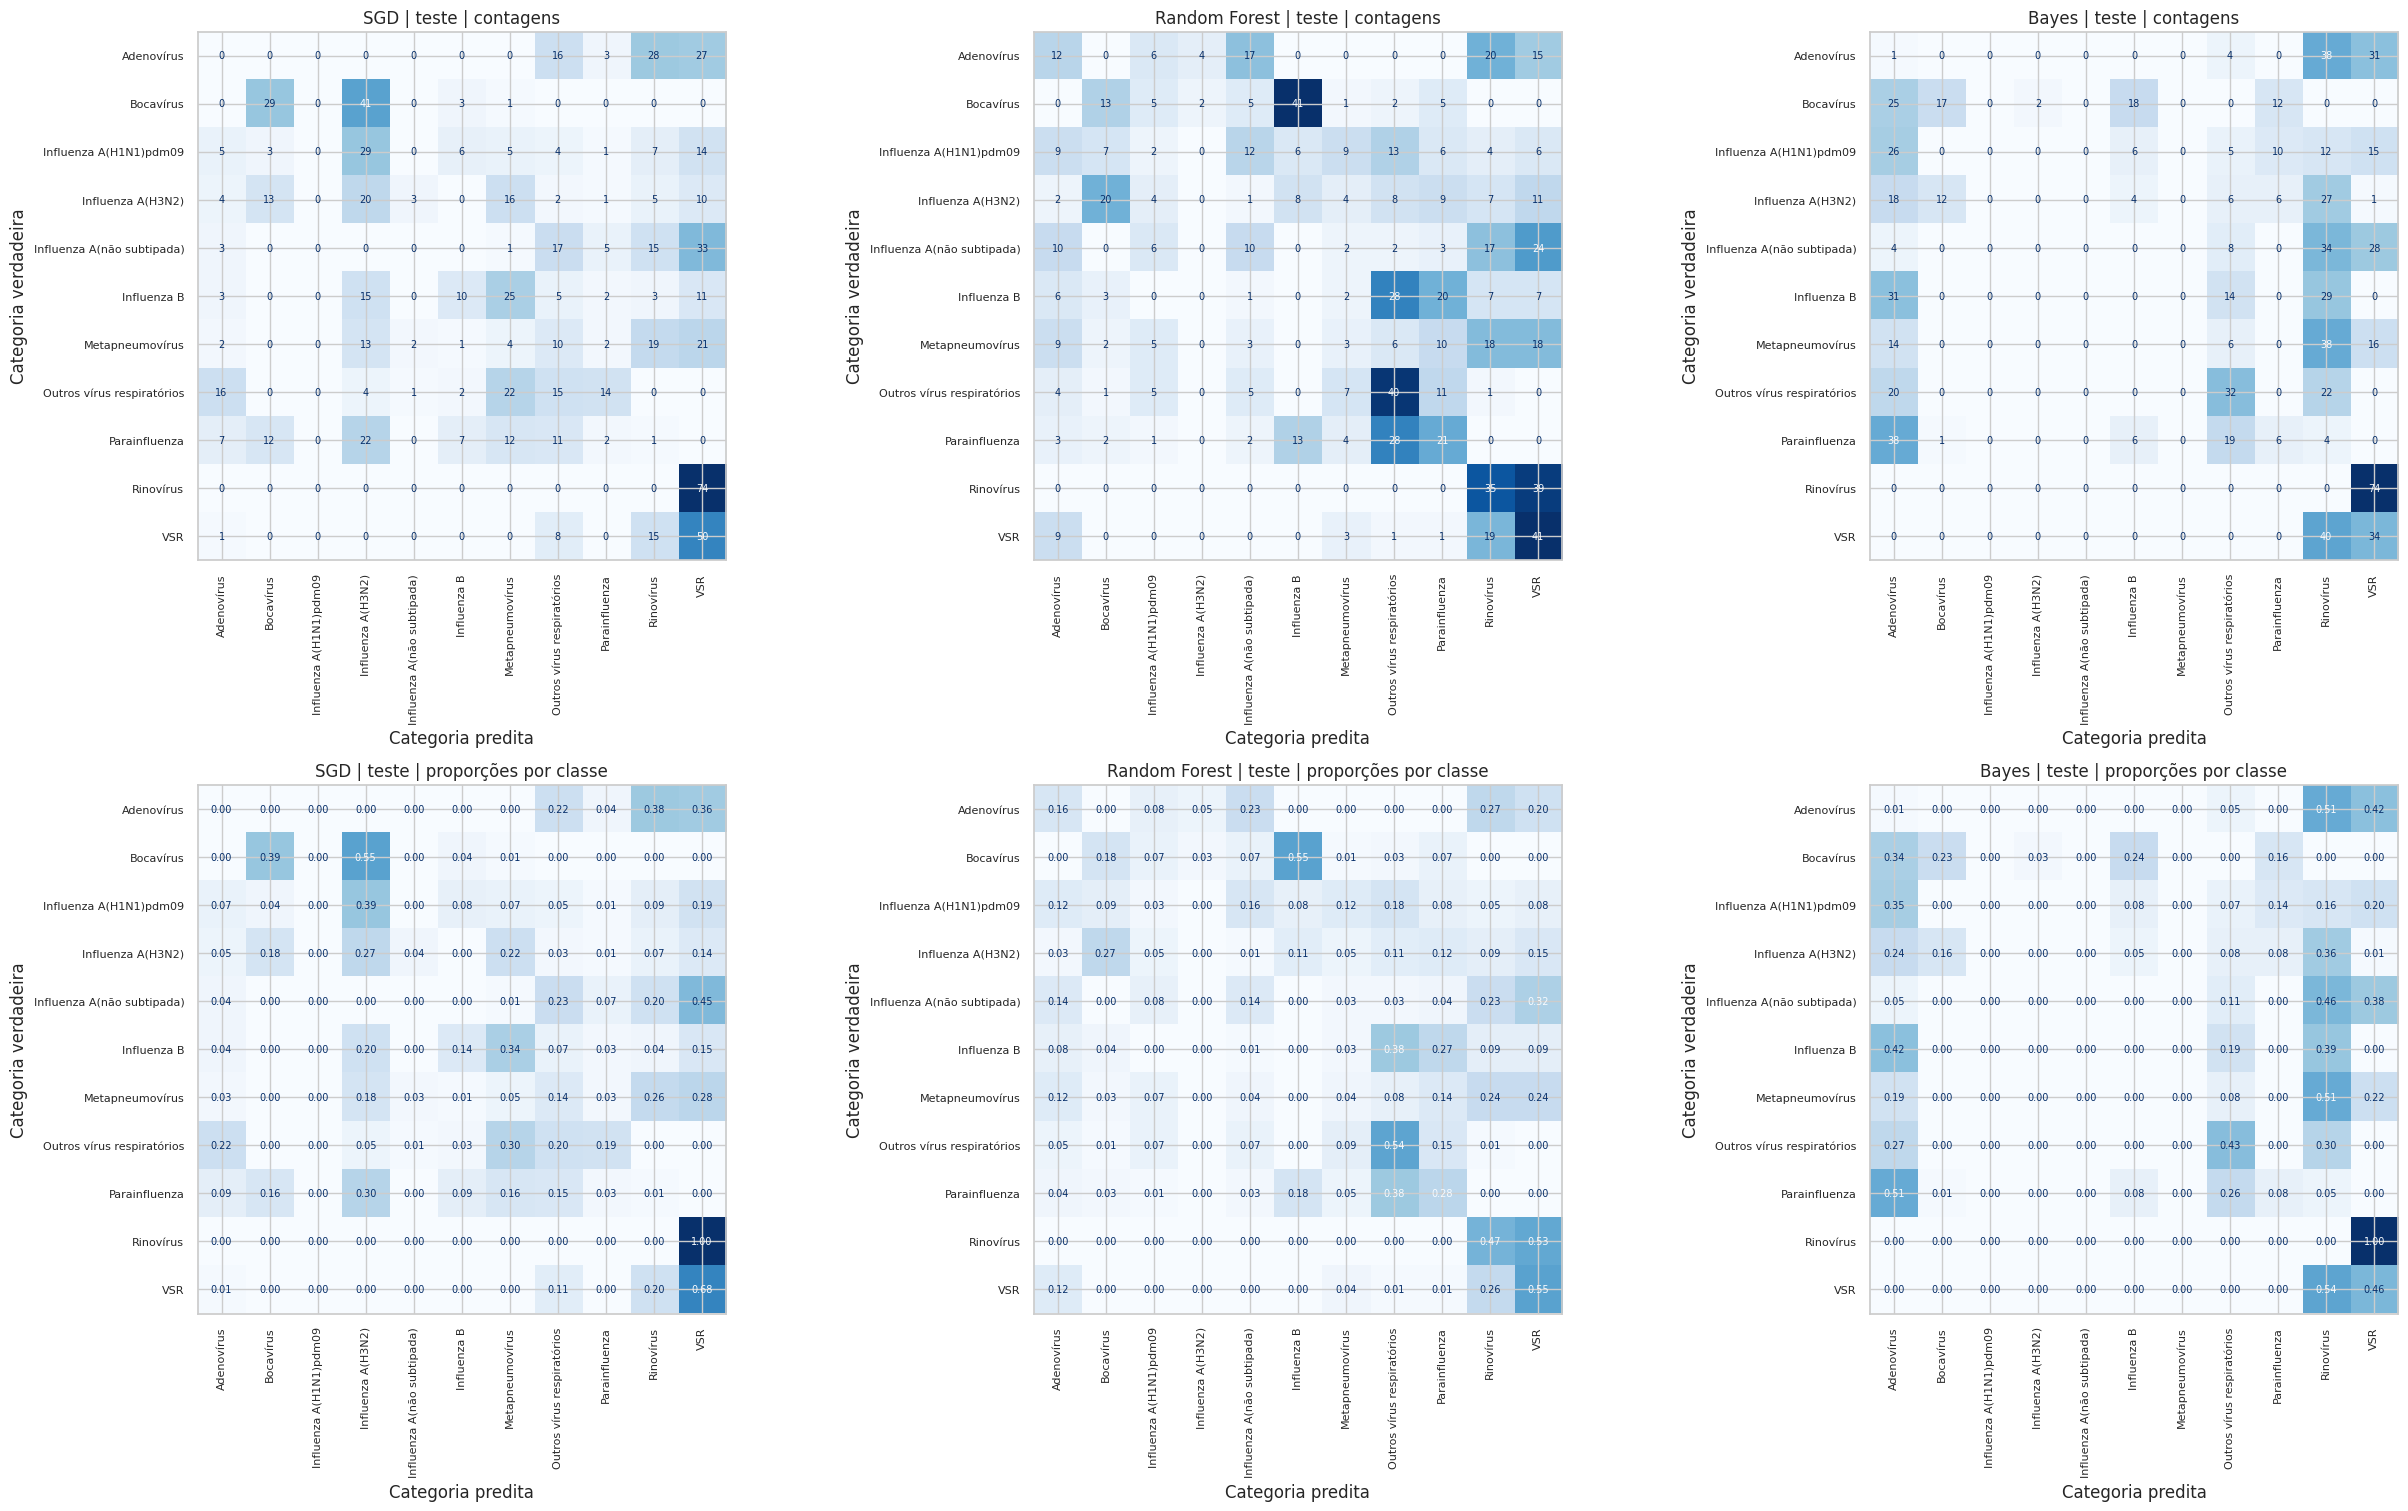

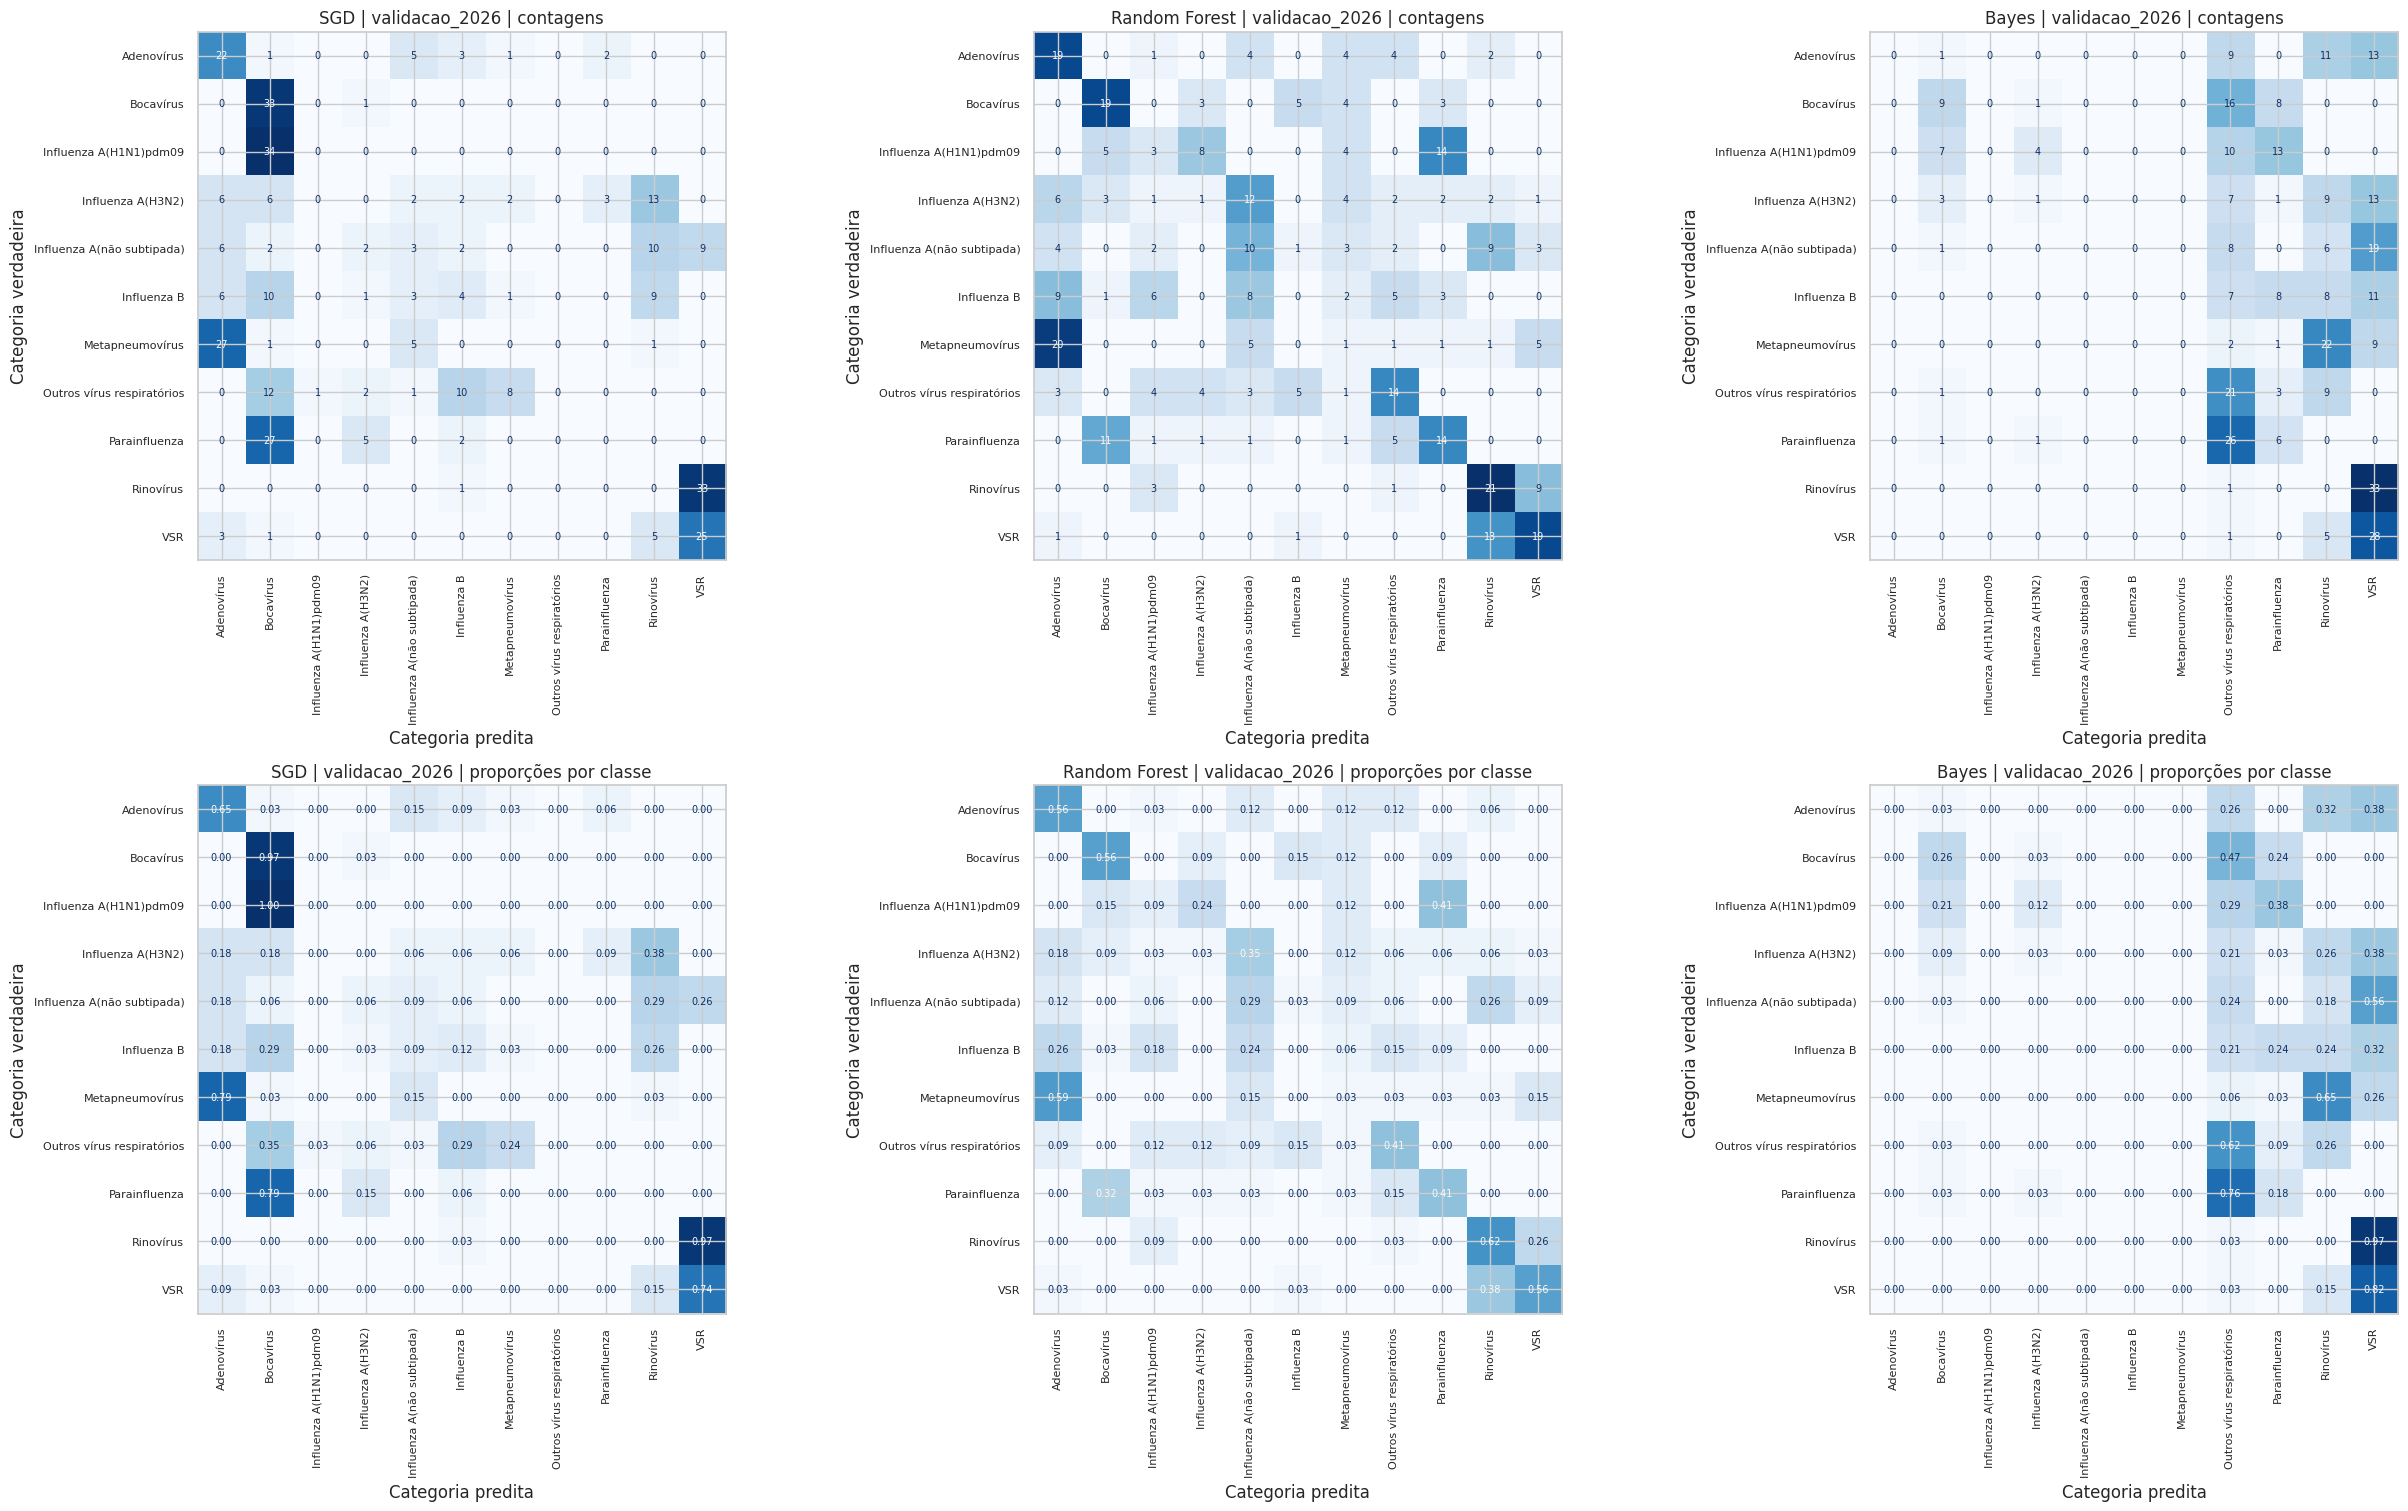

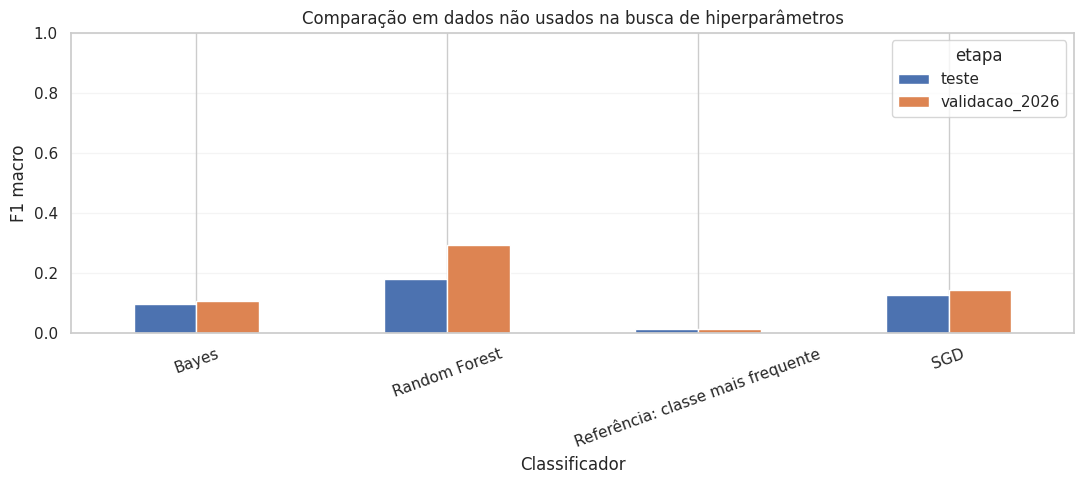

In [11]:
# Matrizes: linhas = classe verdadeira; colunas = classe predita.
for etapa in ["teste", "validacao_2026"]:
    if ("SGD", etapa) not in matrizes_cls:
        continue
    fig, eixos = plt.subplots(2, 3, figsize=(25, 15), constrained_layout=True)
    for coluna, nome in enumerate(especificacoes_cls):
        matriz = matrizes_cls[(nome, etapa)]
        normalizada = np.divide(matriz, matriz.sum(axis=1, keepdims=True),
                               out=np.zeros_like(matriz, dtype=float),
                               where=matriz.sum(axis=1, keepdims=True) != 0)
        for linha, (valores, formato) in enumerate([(matriz, "d"), (normalizada, ".2f")]):
            eixo = eixos[linha, coluna]
            ConfusionMatrixDisplay(valores, display_labels=CLASSES).plot(
                ax=eixo, cmap="Blues", values_format=formato,
                xticks_rotation=90, colorbar=False, im_kw={"vmin": 0, **({"vmax": 1} if linha else {})})
            eixo.set_title(f"{nome} | {etapa} | {'proporções por classe' if linha else 'contagens'}")
            eixo.set_xlabel("Categoria predita")
            eixo.set_ylabel("Categoria verdadeira")
            eixo.tick_params(labelsize=8)
            for texto in eixo.texts:
                texto.set_fontsize(7)
    fig.savefig(PASTA_CLASSIFICACAO / f"matrizes_confusao_{etapa}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

fig, eixo = plt.subplots(figsize=(11, 5))
comparacao_avaliacao.pivot(index="modelo", columns="etapa", values="f1_macro").plot.bar(ax=eixo)
eixo.set(ylabel="F1 macro", xlabel="Classificador", ylim=(0, 1),
         title="Comparação em dados não usados na busca de hiperparâmetros")
eixo.tick_params(axis="x", rotation=20)
eixo.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(PASTA_CLASSIFICACAO / "comparacao_f1_macro.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
